# Task 6: Perturbation Sensitivity Network

This notebook demonstrates **Task 6** of the scGVP downstream analysis pipeline: identifying gene modules with coordinated responses to chemical perturbations and building a gene co-response network.

## Rationale
Genes that respond similarly across multiple perturbations are likely co-regulated or involved in shared pathways. By computing a sensitivity matrix across all perturbations and applying spectral clustering, we can discover gene modules that respond coherently. These modules can be further characterised by pathway enrichment analysis and visualised as a co-response network.

## Key Concepts
- **Sensitivity Score** = |log2FC| × stability, where stability = 1 / (CV_ctrl + CV_ptrb + ε)
- **Sensitivity Matrix** shape: [n_genes × n_perturbations]
- **Spectral clustering** detects modules of co-sensitive genes
- **Co-response network**: genes connected if their Spearman correlation across perturbations ≥ threshold

## Workflow
1. Load model and LINCS dataset
2. Compute gene sensitivity matrix across all perturbations
3. Cluster genes into sensitivity modules
4. Pathway enrichment for each module
5. Build gene co-response network
6. Comprehensive visualisation

## Outputs
- `sensitivity_heatmap.png` — genes × perturbations sensitivity heatmap
- `module_analysis.png` — module size and average sensitivity bar charts
- `sensitivity_network.png` — gene co-response network (core component)
- `module_enrichments.txt` — pathway enrichment per module
- `sensitivity_matrix.csv` — full sensitivity matrix
- `gene_module_assignments.csv` — gene → module mapping

## 1. Imports

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.stats import spearmanr

from model import GINVAE
from dataset import ChunkedGeneGraphDataset
from task6 import PerturbationSensitivityNetwork

print(f"PyTorch: {torch.__version__}")
print(f"Device : {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch: 2.9.0.dev20250827+cu129
Device : cuda


## 2. Configuration

Datasets and model weights are available at:  
**https://huggingface.co/datasets/Mike2481/Dataset4scGVP/tree/main**

In [2]:
MODEL_PATH  = '../src/best_gin_vae_model_node_level.pth'
LINCS_PATH  = '../lincs/merged_all_965_with_morgan.h5ad'
TAHOE_PATHS = [f'../minitahoe/p{i}_with_morgan.h5ad' for i in range(1, 15)]
REF_CACHE   = './output/reference_latents.pkl'
SAVE_DIR    = './output/task2_drug_network'

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs('./output', exist_ok=True)

# Number of perturbations to analyse
N_PERTURBATIONS = 20
# Number of gene modules to detect
N_CLUSTERS = 5
# Correlation threshold for co-response network edges
CORR_THRESHOLD = 0.7

## 3. Load Model

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GINVAE(input_dim=1, hidden_dim=300, latent_dim=100, num_layers=2).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print(f"Model loaded on {device}")

Model loaded on cuda


## 4. Load Data

In [4]:
lincs_adata = sc.read_h5ad(LINCS_PATH)
print(f"LINCS dataset: {lincs_adata.shape[0]} cells × {lincs_adata.shape[1]} genes")
print(f"Unique perturbations: {lincs_adata.obs['canonical_smiles'].nunique()}")

lincs_dataset = ChunkedGeneGraphDataset([LINCS_PATH], split='test')
print(f"Dataset samples: {len(lincs_dataset)}")

LINCS dataset: 157138 cells × 965 genes
Unique perturbations: 8316
Found 32 chunks with 157138 total samples
Dataset samples: 157138


## 5. Process Reference Dataset

In [5]:
model.process_reference_dataset(
    x_ref_dataset=lincs_dataset,
    save_path=REF_CACHE,
    force_reprocess=False
)
print("Reference dataset ready.")

Loading existing processed data from ./output/reference_latents.pkl
Loaded reference data metadata from ./output/reference_latents.pkl
Total samples available: 157138
Loading data from chunks...


Loading chunks: 100%|██████████| 16/16 [00:01<00:00, 12.56it/s, file=chunk_15.pkl]


Loaded and filtered 157138 samples from chunks
Computing biological context from 78569 control and 78569 perturb samples
Extracting graph-level latent representations...


Processing perturb samples: 100%|██████████| 78569/78569 [00:01<00:00, 58251.46it/s]


Computing mean representations...
References computed successfully.
Control ref shape: torch.Size([1, 100]), norm: 3.5154
perturb ref shape: torch.Size([1, 100]), norm: 3.5215
Biological context norm: 0.0068
Reference dataset ready.


## 6. Initialise PerturbationSensitivityNetwork

In [6]:
task6 = PerturbationSensitivityNetwork(model, device)
print("PerturbationSensitivityNetwork initialised.")

PerturbationSensitivityNetwork initialised.


## 7. Compute Gene Sensitivity Matrix

For each perturbation, the log2 fold change (response strength) is weighted by the stability (inverse coefficient of variation). The result is a [n_genes × n_perturbations] sensitivity matrix.

In [7]:
sensitivity_matrix, gene_names, perturbations = task6.compute_gene_sensitivity(
    adata=lincs_adata,
    test_dataset=lincs_dataset,
    n_perturbations=N_PERTURBATIONS
)

print(f"\nSensitivity matrix shape: {sensitivity_matrix.shape}")
print(f"  Rows (genes)         : {len(gene_names)}")
print(f"  Columns (perts)      : {len(perturbations)}")
print(f"  Value range          : [{sensitivity_matrix.min():.4f}, {sensitivity_matrix.max():.4f}]")
print(f"  Mean sensitivity     : {sensitivity_matrix.mean():.4f}")

Computing gene sensitivity across perturbations...


Processing perturbations: 100%|██████████| 20/20 [00:00<00:00, 222.10it/s]


Sensitivity matrix shape: (965, 20)
  Rows (genes)         : 965
  Columns (perts)      : 20
  Value range          : [0.0000, 10.1813]
  Mean sensitivity     : 0.1718


In [8]:
# Save sensitivity matrix
sens_df = pd.DataFrame(
    sensitivity_matrix,
    index=gene_names,
    columns=[str(p)[:30] for p in perturbations]
)
sens_df.to_csv(os.path.join(SAVE_DIR, 'sensitivity_matrix.csv'))
print(f"Sensitivity matrix saved. Top 5 most sensitive genes:")
gene_mean_sensitivity = sensitivity_matrix.mean(axis=1)
top_idx = np.argsort(gene_mean_sensitivity)[-5:][::-1]
for idx in top_idx:
    print(f"  {gene_names[idx]:12s}: mean sensitivity = {gene_mean_sensitivity[idx]:.4f}")

Sensitivity matrix saved. Top 5 most sensitive genes:
  EPHB2       : mean sensitivity = 0.7016
  DNAJA3      : mean sensitivity = 0.6317
  IKZF1       : mean sensitivity = 0.6275
  GNAS        : mean sensitivity = 0.5886
  PRKCH       : mean sensitivity = 0.5858


## 8. Sensitivity Heatmap — Top Sensitive Genes

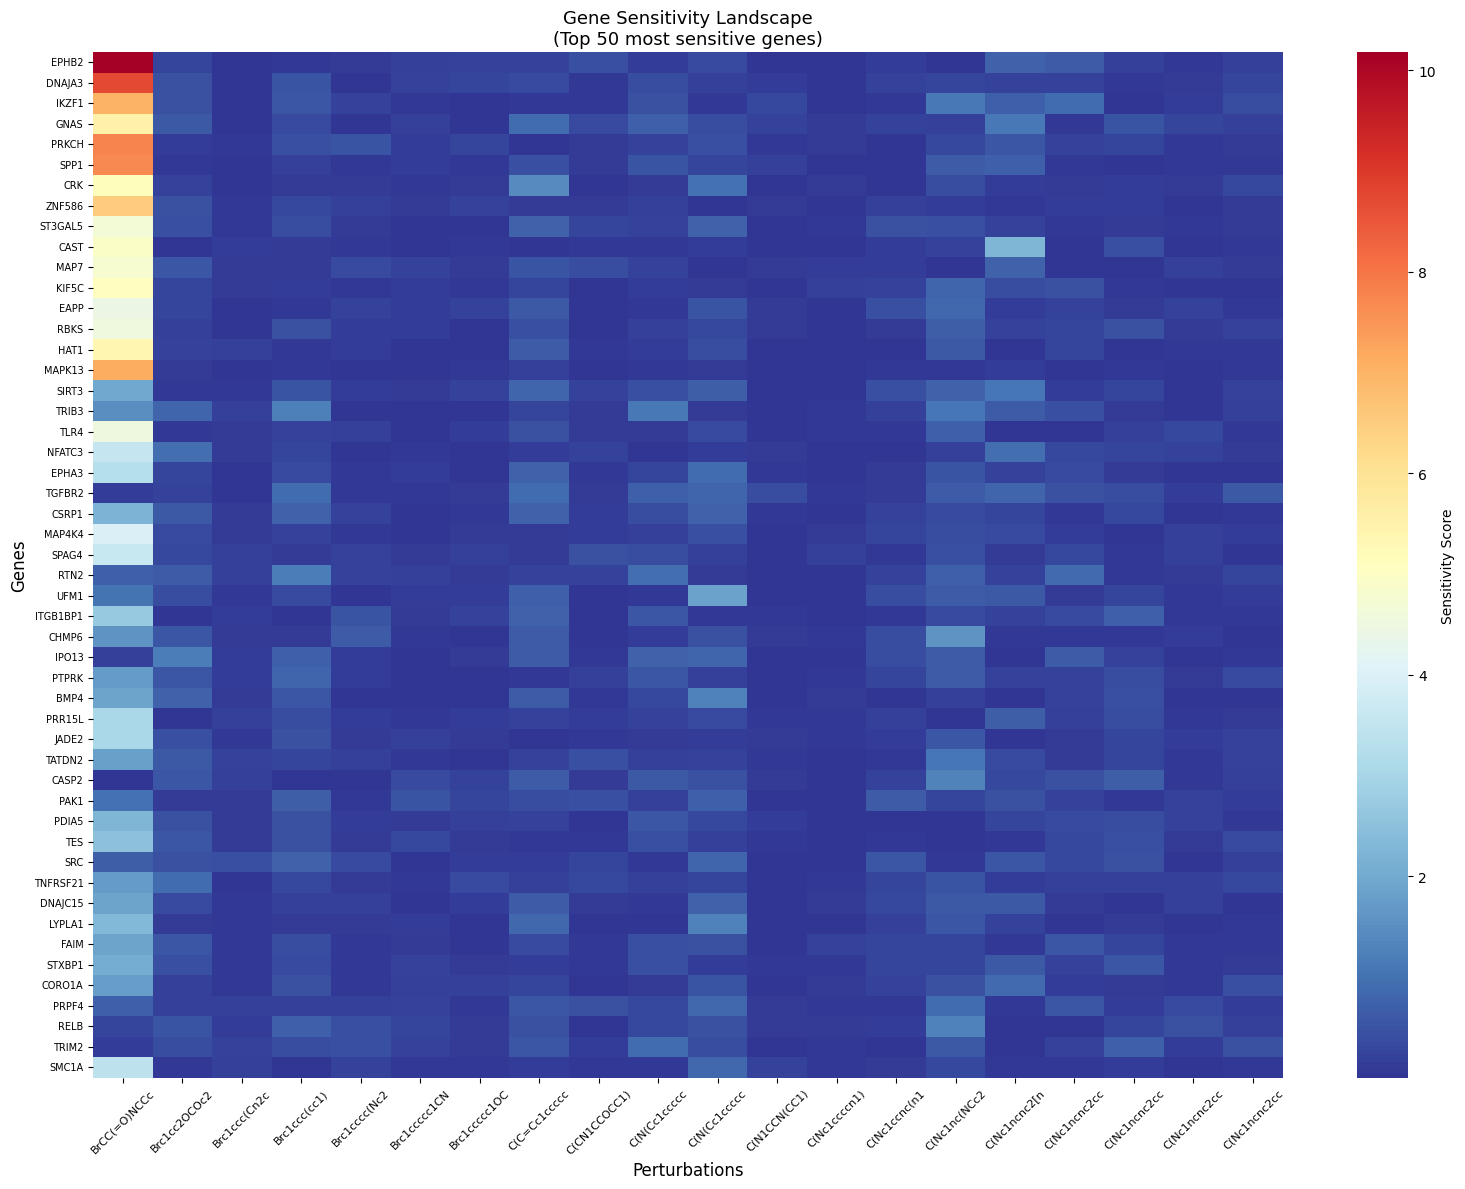

In [9]:
# Show top 50 most sensitive genes
n_genes_show = min(50, len(gene_names))
top_gene_idx = np.argsort(gene_mean_sensitivity)[-n_genes_show:][::-1]
sub_matrix = sensitivity_matrix[top_gene_idx, :]
sub_genes  = [gene_names[i] for i in top_gene_idx]
ptrb_labels = [str(p)[:12] for p in perturbations]

fig, ax = plt.subplots(figsize=(max(10, len(perturbations)*0.8), 12))
sns.heatmap(
    sub_matrix,
    ax=ax,
    cmap='RdYlBu_r',
    xticklabels=ptrb_labels,
    yticklabels=sub_genes,
    cbar_kws={'label': 'Sensitivity Score'}
)
ax.set_xlabel('Perturbations', fontsize=12)
ax.set_ylabel('Genes', fontsize=12)
ax.set_title(f'Gene Sensitivity Landscape\n(Top {n_genes_show} most sensitive genes)', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'sensitivity_heatmap_preview.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Identify Sensitivity Modules

Spectral clustering groups genes that share similar sensitivity profiles across perturbations.

In [10]:
modules, labels = task6.identify_sensitive_modules(
    sensitivity_matrix=sensitivity_matrix,
    gene_names=gene_names,
    n_clusters=N_CLUSTERS
)

print(f"\n✓ Identified {len(modules)} gene modules:")
for module_name, module_data in modules.items():
    print(f"  {module_name}: {module_data['n_genes']} genes, "
          f"avg sensitivity = {module_data['avg_sensitivity']:.4f}")
    print(f"    Sample genes: {module_data['genes'][:5]}")

Identifying 5 gene modules...

✓ Identified 5 gene modules:
  Module_1: 58 genes, avg sensitivity = 0.1762
    Sample genes: ['GNPDA1', 'PARP2', 'SMC4', 'KIF20A', 'CEBPZ']
  Module_2: 528 genes, avg sensitivity = 0.1433
    Sample genes: ['CDH3', 'HDAC6', 'DNAJB6', 'ABCC5', 'ABCB6']
  Module_3: 133 genes, avg sensitivity = 0.2344
    Sample genes: ['ARL4C', 'MBNL2', 'CDK4', 'MFSD10', 'IKZF1']
  Module_4: 58 genes, avg sensitivity = 0.2135
    Sample genes: ['LYPLA1', 'RRAGA', 'CETN3', 'WASF3', 'EBNA1BP2']
  Module_5: 188 genes, avg sensitivity = 0.1936
    Sample genes: ['MAMLD1', 'DNM1L', 'G3BP1', 'SLC25A13', 'RBM6']


In [11]:
# Save gene → module mapping
module_assignment = pd.DataFrame({
    'gene': gene_names,
    'module': [f'Module_{l+1}' for l in labels]
})
module_assignment['mean_sensitivity'] = gene_mean_sensitivity
module_assignment = module_assignment.sort_values(['module', 'mean_sensitivity'], ascending=[True, False])
module_assignment.to_csv(os.path.join(SAVE_DIR, 'gene_module_assignments.csv'), index=False)
print("Gene module assignments saved.")
display(module_assignment.head(15))

Gene module assignments saved.


,gene,module,mean_sensitivity
789,CHMP6,Module_1,0.333720
652,RELB,Module_1,0.303892
679,ABHD4,Module_1,0.284323
11,KIF20A,Module_1,0.276931
763,USP1,Module_1,0.267939
368,DNAJB2,Module_1,0.266903
866,CCNA2,Module_1,0.266118
726,SUV39H1,Module_1,0.248124
889,CCNE2,Module_1,0.246371
895,AURKB,Module_1,0.244640


## 10. Module Size and Sensitivity Profile

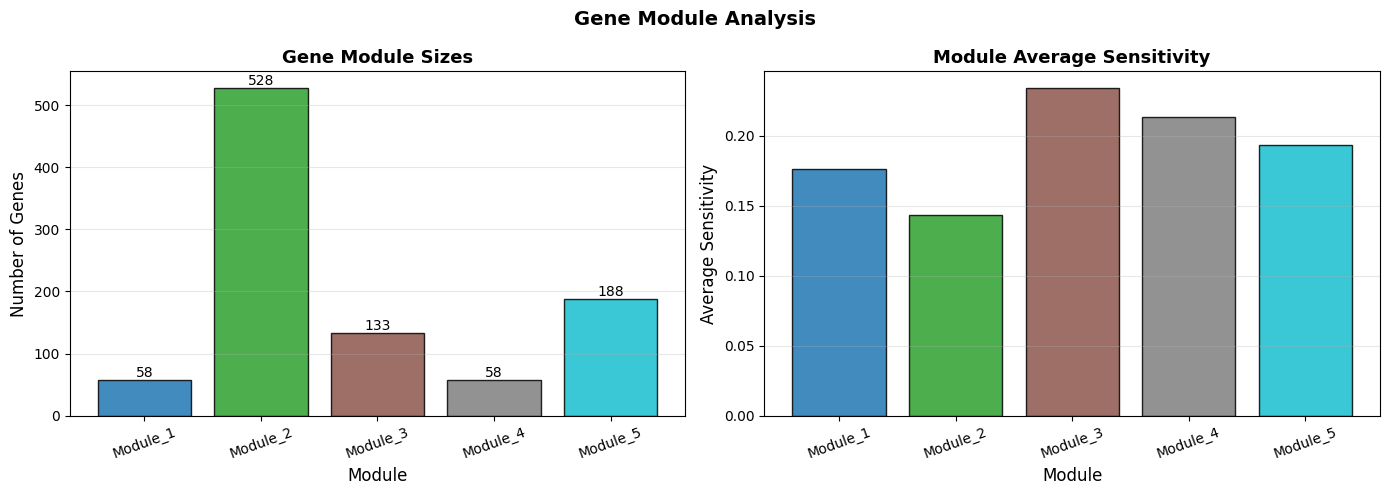

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

module_names       = list(modules.keys())
module_sizes       = [m['n_genes'] for m in modules.values()]
module_avg_sens    = [m['avg_sensitivity'] for m in modules.values()]

palette = plt.cm.tab10(np.linspace(0, 1, len(module_names)))

axes[0].bar(module_names, module_sizes, color=palette, alpha=0.85, edgecolor='black')
axes[0].set_xlabel('Module', fontsize=12)
axes[0].set_ylabel('Number of Genes', fontsize=12)
axes[0].set_title('Gene Module Sizes', fontsize=13, fontweight='bold')
for i, v in enumerate(module_sizes):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10)
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(module_names, module_avg_sens, color=palette, alpha=0.85, edgecolor='black')
axes[1].set_xlabel('Module', fontsize=12)
axes[1].set_ylabel('Average Sensitivity', fontsize=12)
axes[1].set_title('Module Average Sensitivity', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Gene Module Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'module_analysis_preview.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11. Module Sensitivity Profiles Across Perturbations

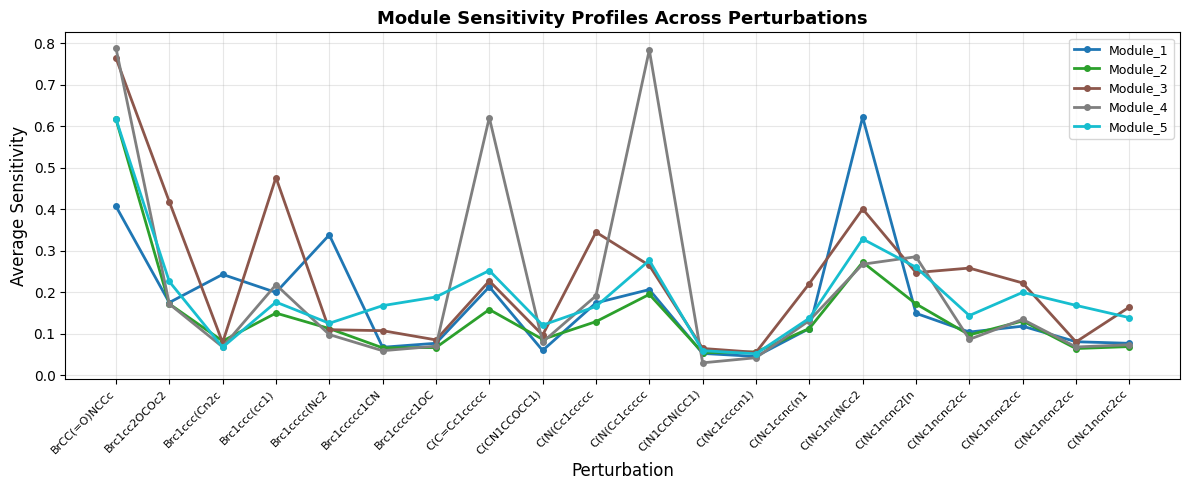

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(perturbations))

for (module_name, module_data), color in zip(modules.items(), palette):
    profile = module_data['sensitivity_profile']
    ax.plot(x, profile, label=module_name, color=color, linewidth=2, marker='o', markersize=4)

ax.set_xticks(x)
ax.set_xticklabels([str(p)[:12] for p in perturbations], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Perturbation', fontsize=12)
ax.set_ylabel('Average Sensitivity', fontsize=12)
ax.set_title('Module Sensitivity Profiles Across Perturbations', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'module_profiles.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Module Pathway Enrichment Analysis

In [14]:
print("Running pathway enrichment for each module (requires internet access to STRING API)...")
module_enrichments = task6.analyze_module_enrichment(modules)

# Save enrichment results
enrich_path = os.path.join(SAVE_DIR, 'module_enrichments.txt')
with open(enrich_path, 'w') as f:
    for module_name, enrich_df in module_enrichments.items():
        f.write(f"\n{'='*60}\n{module_name}\n{'='*60}\n")
        f.write(enrich_df.to_string())
        f.write("\n")

print(f"Enrichment results saved to: {enrich_path}")
print(f"Modules with enrichment: {len(module_enrichments)}")

# Display enrichment for the first module
for module_name, enrich_df in module_enrichments.items():
    print(f"\n{module_name} — Top enriched pathways:")
    display(enrich_df[['category', 'description', 'fdr', 'n_genes']].head(10))
    break

Running pathway enrichment for each module (requires internet access to STRING API)...
Performing pathway enrichment for modules...
Enrichment results saved to: ./output/task2_drug_network/module_enrichments.txt
Modules with enrichment: 4

Module_1 — Top enriched pathways:


,category,description,fdr,n_genes
0,KEGG,MicroRNAs in cancer,0.000010,8
1,KEGG,DNA replication,0.000014,5
2,KEGG,Base excision repair,0.000014,5
3,KEGG,Cell cycle,0.000014,7
4,KEGG,Cellular senescence,0.000025,7
5,KEGG,Progesterone-mediated oocyte maturation,0.000620,5
6,KEGG,Nucleotide excision repair,0.000670,4
7,KEGG,Viral carcinogenesis,0.000800,6
8,KEGG,Mismatch repair,0.002200,3
9,KEGG,Epstein-Barr virus infection,0.009400,5


## 13. Build Gene Co-Response Network

Genes with Spearman correlation ≥ threshold across perturbation profiles are connected in the co-response network.

In [15]:
print(f"Building co-response network (correlation threshold = {CORR_THRESHOLD})...")
co_network, corr_matrix = task6.build_sensitivity_network(
    sensitivity_matrix=sensitivity_matrix,
    gene_names=gene_names,
    threshold=CORR_THRESHOLD
)

print(f"\nCo-response network:")
print(f"  Nodes (genes with co-responses): {co_network.number_of_nodes()}")
print(f"  Edges (correlated gene pairs)  : {co_network.number_of_edges()}")

if co_network.number_of_nodes() > 0:
    # Compute basic network statistics
    density = nx.density(co_network)
    components = nx.number_connected_components(co_network)
    print(f"  Network density                : {density:.4f}")
    print(f"  Connected components           : {components}")

Building co-response network (correlation threshold = 0.7)...
Building gene sensitivity co-response network...
Network: 863 nodes, 4746 edges

Co-response network:
  Nodes (genes with co-responses): 863
  Edges (correlated gene pairs)  : 4746
  Network density                : 0.0128
  Connected components           : 11


## 14. Visualise Co-Response Network

In [16]:
if co_network.number_of_nodes() > 0:
    # Use largest connected component
    largest_cc = max(nx.connected_components(co_network), key=len)
    G_core = co_network.subgraph(largest_cc).copy()

    if G_core.number_of_nodes() <= 200:
        fig, ax = plt.subplots(figsize=(14, 12))

        # Colour nodes by module assignment
        gene_to_module = {g: l for g, l in zip(gene_names, labels)}
        node_colors = [gene_to_module.get(n, 0) for n in G_core.nodes()]
        node_sizes  = [dict(G_core.degree())[n] * 30 + 50 for n in G_core.nodes()]

        try:
            pos = nx.spring_layout(G_core, k=1.0/np.sqrt(G_core.number_of_nodes()), seed=42)
        except Exception:
            pos = nx.circular_layout(G_core)

        nx.draw_networkx_edges(G_core, pos, alpha=0.2, width=0.8, ax=ax)
        sc_nodes = nx.draw_networkx_nodes(
            G_core, pos,
            node_color=node_colors, cmap=plt.cm.tab10,
            node_size=node_sizes, alpha=0.85, ax=ax
        )

        # Label high-degree hubs
        degree_dict = dict(G_core.degree())
        hub_nodes = sorted(degree_dict, key=lambda n: degree_dict[n], reverse=True)[:10]
        hub_labels = {n: n for n in hub_nodes}
        nx.draw_networkx_labels(G_core, pos, labels=hub_labels, font_size=8, ax=ax)

        plt.colorbar(sc_nodes, ax=ax, label='Module Index', shrink=0.6)
        ax.set_title(
            f'Gene Co-Response Network\n'
            f'({G_core.number_of_nodes()} nodes, {G_core.number_of_edges()} edges, '
            f'threshold={CORR_THRESHOLD})',
            fontsize=13
        )
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_DIR, 'sensitivity_network_preview.png'), dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print(f"Network too large to display inline ({G_core.number_of_nodes()} nodes). "
              "Use perform_complete_analysis to save the full visualisation.")
else:
    print("No co-response network built (try lowering CORR_THRESHOLD).")

Network too large to display inline (838 nodes). Use perform_complete_analysis to save the full visualisation.


## 15. Full Pipeline — perform_complete_analysis

The `perform_complete_analysis` method runs all steps (sensitivity → modules → enrichment → network → visualisations) in one call and saves all outputs to `save_dir`.

In [17]:
complete_dir = os.path.join(SAVE_DIR, 'complete_analysis')

results = task6.perform_complete_analysis(
    adata=lincs_adata,
    test_dataset=lincs_dataset,
    n_perturbations=N_PERTURBATIONS,
    n_clusters=N_CLUSTERS,
    save_dir=complete_dir
)

print(f"\n✓ Complete analysis finished.")
print(f"  Sensitivity matrix shape : {results['sensitivity_matrix'].shape}")
print(f"  Number of modules        : {len(results['modules'])}")
print(f"  Modules with enrichment  : {len(results['enrichments'])}")
print(f"  Network nodes            : {results['network'].number_of_nodes()}")
print(f"  Network edges            : {results['network'].number_of_edges()}")
print(f"\nAll figures saved to: {complete_dir}")

Computing gene sensitivity across perturbations...


Processing perturbations: 100%|██████████| 20/20 [00:00<00:00, 223.82it/s]

Identifying 5 gene modules...


Performing pathway enrichment for modules...
Building gene sensitivity co-response network...
Network: 863 nodes, 4746 edges
Visualizations saved to ./output/task2_drug_network/complete_analysis/

✓ Complete analysis finished.
  Sensitivity matrix shape : (965, 20)
  Number of modules        : 5
  Modules with enrichment  : 4
  Network nodes            : 863
  Network edges            : 4746

All figures saved to: ./output/task2_drug_network/complete_analysis


## 16. Summary

In [18]:
print("=" * 60)
print("Task 6: Perturbation Sensitivity Network — Summary")
print("=" * 60)
print(f"  Perturbations analysed   : {len(perturbations)}")
print(f"  Total genes              : {len(gene_names)}")
print(f"  Gene modules detected    : {len(modules)}")
for module_name, module_data in modules.items():
    print(f"    {module_name}: {module_data['n_genes']} genes, "
          f"avg sensitivity = {module_data['avg_sensitivity']:.4f}")
print(f"  Co-response network:")
print(f"    Nodes                  : {co_network.number_of_nodes()}")
print(f"    Edges                  : {co_network.number_of_edges()}")
print(f"    Correlation threshold  : {CORR_THRESHOLD}")
print(f"\nAll outputs saved to: {SAVE_DIR}")

Task 6: Perturbation Sensitivity Network — Summary
  Perturbations analysed   : 20
  Total genes              : 965
  Gene modules detected    : 5
    Module_1: 58 genes, avg sensitivity = 0.1762
    Module_2: 528 genes, avg sensitivity = 0.1433
    Module_3: 133 genes, avg sensitivity = 0.2344
    Module_4: 58 genes, avg sensitivity = 0.2135
    Module_5: 188 genes, avg sensitivity = 0.1936
  Co-response network:
    Nodes                  : 863
    Edges                  : 4746
    Correlation threshold  : 0.7

All outputs saved to: ./output/task2_drug_network
